# Sensitivity to solar radiation, subsidence and treatment of ice surface
The notebook below shows sensitivity tests during specification development. We used 200-m resolution on a 25-km domain as an adequate setup to evaluate sensitivity. All simulations use DHARMA's default roughness lengths.
* **DHARMA-MIZ-RAD_Lx25km_dx200_FixN -**
We started with this more complex set-up: Upstream of the ice edge, the surface was treated as an ice surface of specified temperature and a fixed roughness length of 0.0001 m. Downstream of the ice edge, Charnock's relation was used for roughness over a water surface. Both solar and longwave radiation were included.
* **DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff -**
Turning off solar radiation had little effect, so that was omitted.
* **DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff_Wsub -**
Turning on large-scale subsidence derived from ERA5 had little effect, so that was omitted. This avoided the need for offsetting specifications to avoid spurious thermodynamic evolution owing to disconinuity at domain top. Omitting subsidence also greatly simplifies analyses for process understanding.
* **DHARMA-MIZ-RAD_Lx25km_dx200_FixN_noMIZ -**
Treating the ice surface as a water surface that is supercooled enough to match ice surface surface fluxes also had little effect. This greatly simplifies the setup especially for Earth system model codes run in single-column model mode. Since it also had negligible effect that we could identify in LES, this was adopted as a helpful simplification. Thanks to Mikhail Ovchinnikov and Peng Wu for sharing this approach.  

We consider the differences between all of the simulations shown below to be within the uncertainty of the specification derivation. We then proceeded to test sensitivity to roughness lengths in both DHARMA and WRF.

Source: Ann Fridlind (ann.fridlind@nasa.gov), Andrew Ackerman (andrew.ackerman@nasa.gov), and Florian Tornow (ft2544@columbia.edu)

In [36]:
import os

In [37]:
os.chdir("/user-data-home/comble-mip/notebooks/plotting/paper/")

%run functions_plotting.py

os.chdir("/user-data-home/comble-mip/notebooks/plotting/")


In [38]:
## select simulations to plot
#sim_keyword = 'DHARMA_Lx25km_dx200_z0_'

## load ERA5 fields
era5_1d, era5_2d = load_era5(PATH='../../data_files/')

## load radiosondes
rs_dat = load_rs(t_filter = 6.)

## load DOE ARM site statistics
aeri_dat = load_aeri(t_filter = 0.5)

## load MAC-LWP
maclwp_dat = load_maclwp(t_filter = 0.) 

## load CALIPSO retrievals (note the increased time window)
calipso_dat = load_calipso(t_filter = 3.)

../../data_files/theta_temp_rh_sh_uvw_sst_along_trajectory_era5ml_28h_end_2020-03-13-18.nc
../../data_files/anxsondewnpnM1.b1.20200313.052700.cdf
../../data_files/anxsondewnpnM1.b1.20200313.112600.cdf
../../data_files/anxsondewnpnM1.b1.20200313.172600.cdf
../../data_files/anxsondewnpnM1.b1.20200313.232200.cdf
new +/- 20% error!


In [39]:

## select simulations to plot
sim_keyword = 'MIZ-RAD'

## load all simulations located in subfolders of the given directory
var_vec_1d = ['hfss','hfls','ts','lwpr','lwpc','iwp','od','rlut']
var_vec_2d = ['theta','qv','qlc','qlr','qic','qis','qig','ua','va','ta','prf','huri']
df_col_1d,df_col_2d = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword,diag_zi_ctt=True)

Loading variables: f(time)
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_noMIZ.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff_Wsub.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff.nc
Loading variables: f(time,height)
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_noMIZ.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff_Wsub.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN.nc
../../output_les/dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff.nc
computing inversion height, cloud-top height, and cloud-top temperature
using liquid(-ice) potential temperature
dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN.nc
dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff.nc
dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_SWoff_Wsub.nc
dharma/devel/DHARMA-MIZ-RAD_Lx25km_dx200_FixN_noMIZ.nc


In [40]:
sim_keyword = 'nudgedwind'
df_col_1d2,df_col_2d2 = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword,diag_zi_ctt=True,QTHRES=4.0e-5)

Loading variables: f(time)
../../output_les/dharma/sandbox/DHARMA_Lx25_dx100_FixN_nudgedwind.nc
Loading variables: f(time,height)
../../output_les/dharma/sandbox/DHARMA_Lx25_dx100_FixN_nudgedwind.nc
computing inversion height, cloud-top height, and cloud-top temperature
using liquid(-ice) potential temperature
dharma/sandbox/DHARMA_Lx25_dx100_FixN_nudgedwind.nc


In [41]:
sim_keyword = 'DHARMA_Lx25_dx100_FixN.'
df_col_1d3,df_col_2d3 = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword,diag_zi_ctt=True,QTHRES=4.0e-5)

Loading variables: f(time)
../../output_les/dharma/sandbox/DHARMA_Lx25_dx100_FixN.nc
Loading variables: f(time,height)
../../output_les/dharma/sandbox/DHARMA_Lx25_dx100_FixN.nc
computing inversion height, cloud-top height, and cloud-top temperature
using liquid(-ice) potential temperature
dharma/sandbox/DHARMA_Lx25_dx100_FixN.nc


In [42]:
df_col_1d = pd.concat([df_col_1d2,df_col_1d3])
df_col_2d = pd.concat([df_col_2d2,df_col_2d3])

In [43]:
df_col_1d['sim'] = df_col_1d['class'].copy

In [44]:
sims = df_col_1d['class'].unique()

In [46]:
print(sims)
#newsims = ['Baseline','SW off','SW off, subsidence', 'No MIZ','Baseline (100m)','Wind Nudging']print(sims)
newsims = ['Nudged Winds','Baseline']

['dharma/sandbox/DHARMA_Lx25_dx100_FixN_nudgedwind.nc'
 'dharma/sandbox/DHARMA_Lx25_dx100_FixN.nc']


In [47]:
df_col_1d.loc[df_col_1d['class'] == sims[0],['class']] = newsims[0]
df_col_1d.loc[df_col_1d['class'] == sims[1],['class']] = newsims[1]

In [48]:
## double-check if loaded correct runs

path_org = '/data/home/floriantornow/dharma/sandbox/case0313_diag_ice25_dx100_specZ0_windnudge/0-20h/dharma.scalars.cdf'
DHARMA_ORG = xr.open_dataset(path_org)

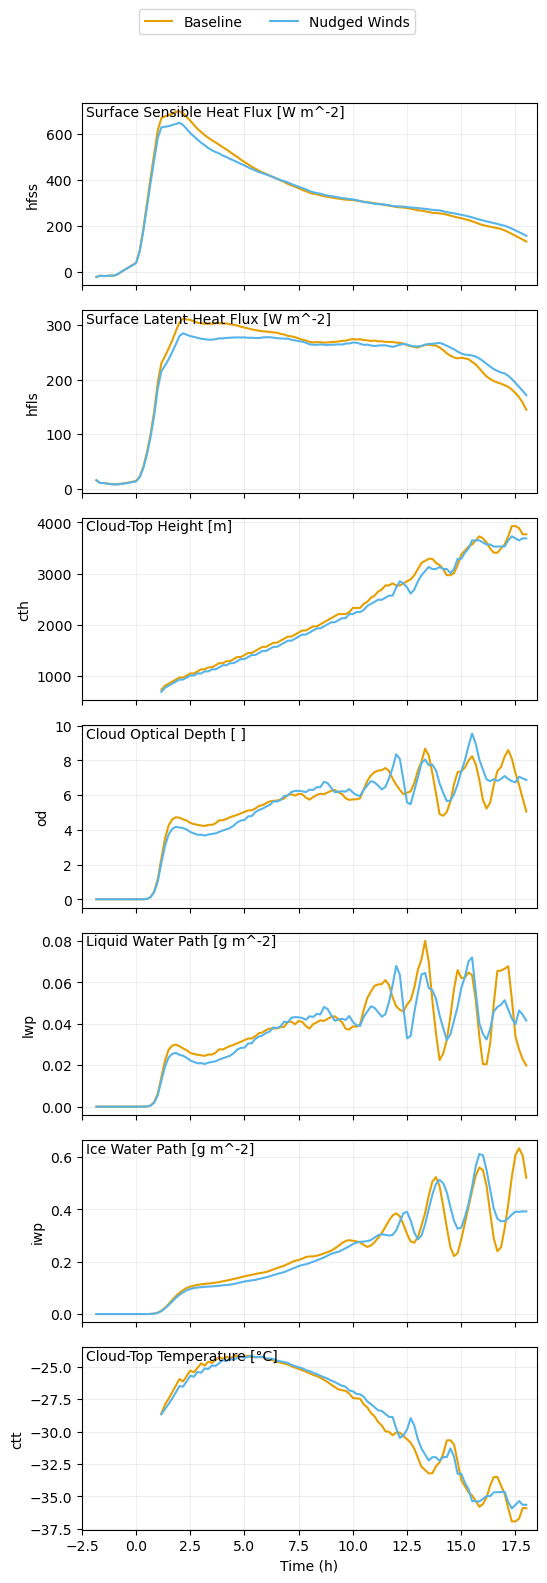

In [50]:
## plot variables that have only time dependence
plot_1d(pd.concat([df_col_1d]),['hfss','hfls','cth','od','lwp','iwp','ctt'],longnames=['Surface Sensible Heat Flux','Surface Latent Heat Flux', 'Cloud-Top Height','Cloud Optical Depth','Liquid Water Path','Ice Water Path','Cloud-Top Temperature'],units=['W m^-2','W m^-2','m',' ','g m^-2','g m^-2','°C'],savepng=True)

In [52]:

list_class = df_col_1d['class'].unique()
list_class

array(['Nudged Winds', 'Baseline'], dtype=object)

In [53]:
## make nicer for paper
col_labs = ['Nudged Winds','Baseline']
mcolors = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288",'grey']
plot_label = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)']
    
plt.figure(figsize=(6,17))
###############################################################################################
### HFSS & HFLS
###############################################################################################
TOT_ROW = 8
pltvar = ['hfss','hfls','cth','od','lwp','iwp','ctt','rlut']
pltlab = ['Sens. Heat\nFlux [W m$^{-2}$]','Lat. Heat\nFlux [W m$^{-2}$]','Cloud Top Height [m]','Cloud Optical Depth [-]','LWP [kg m$^{-2}$]','IWP [kg m$^{-2}$]','Cloud Top Temp. [$^{\circ}$C]','TOA Outgoing\nLW Flux [W m$^{-2}$]']

for ii in np.arange(len(pltvar)):
    ax1 = plt.subplot(TOT_ROW,1,ii+1)
    for i in np.arange(len(list_class)):
        df_filtered = df_col_1d[df_col_1d['class'] == list_class[i]]        
        
        plt.grid(True)
        plt.plot(df_filtered.time/3600,df_filtered[pltvar[ii]],lw=2.,c=mcolors[i],label=col_labs[i])
    #if ii < 2:
    #    plt.plot(era5_1d.time[18:-2]/3600,era5_1d[pltvar[ii]][18:-2],label='ERA5',c='k',lw=2.)
    plt.ylabel(pltlab[ii])
    
    plt.xlim(-3,19)
    xticks_arr = np.arange(-2,20,2)
    if ii == 7:
        plt.xlabel('Time [h]')
    if ii != 7:
        plt.xticks(xticks_arr,['','','','','','','','','','',''])
    ax1.annotate(plot_label[ii], xy=(0.025, 0.9), xycoords='axes fraction', fontsize=12, fontweight='bold')
    
    if ii == 1:
        handles2, labels2 = ax1.get_legend_handles_labels()
    
    if ii == 6:
        plt.legend(handles=handles2,labels=labels2,ncol=1,loc='lower left')

plt.savefig('./paper/model_obs_ts_wind_R1.png',dpi=600,bbox_inches='tight')
plt.close()
plt.show()



In [55]:
unique_values_FixN = df_col_1d['class'].unique()
unique_values_FixN

array(['Nudged Winds', 'Baseline'], dtype=object)

In [59]:
df_col_2d.loc[df_col_2d['class'] == sims[0],['class']] = newsims[0]
df_col_2d.loc[df_col_2d['class'] == sims[1],['class']] = newsims[1]


In [61]:
FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM','SCALE']
FixN_labs = ['Nudged Winds','Baseline']
# Define a list of colorblind-friendly colors
mcolors = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288",'grey']

x_lim_th_1 = [252.,289.]
x_lim_th_2 = [260.,287.]
x_lim_qv_1 = [-0.00005,0.0014]
x_lim_qv_2 = [-0.0001,0.00255]
x_lim_rh_1 = [0.25,1.45]
x_lim_rh_2 = [0.2,1.45]
x_lim_ws_1 = [16.,29.]
x_lim_ws_2 = [5.5,18.5]
x_lim_wd_1 = [341.,366.]
x_lim_wd_2 = [290.,360.]

# OLD
#FixN_labs = ['WRF','SAM','CM1','DALES','UCLALES-SALSA','MSU RCC DM','DHARMA','MIMICA','ICON']
## Define a list of colorblind-friendly colors
#mcolors = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.figure(figsize=(14,9))
###############################################################################################
### HFSS & HFLS
###############################################################################################
pltvar = ['theta','qv','huri','ws','wd']
pltlab = ['Sens. Heat\nFlux [W m$^{-2}$]','Lat. Heat\nFlux [W m$^{-2}$]']
t_ave = 1.
t_arr = [4.,18.]
count = 0
z_max = 5500.
for jj in np.arange(len(t_arr)):
    for ii in np.arange(len(pltvar)):
        axx = plt.subplot(2,5,count+1)
        for i in np.arange(len(unique_values_FixN)):
            if i == 0:
                ## DO ERA5
                df_filtered = era5_2d
                df_filtered = df_filtered[df_filtered['zf'] < (z_max + 500)]
                df_sub = df_filtered[abs(round(df_filtered.time)-t_arr[jj]*3600.)<2.]
                #df_sub = df_filtered[round(df_filtered.time) == 18.*3600.]
                df_ave = df_sub.groupby('zf').mean(numeric_only=True)
                df_ave['zf'] = df_ave.index
                if 'colflag' in set(df_sub):
                    df_ave['colflag'] = df_sub['colflag'].unique()[0]

                df_ave['ws'] = np.sqrt(df_ave['ua']**2 + df_ave['va']**2)
                df_ave['wd'] = np.arctan2(df_ave['ua']/df_ave['ws'],df_ave['va']/df_ave['ws'])*180/np.pi + 180.
                ## avoid jumps
                df_ave.loc[df_ave['wd'] < 10,'wd'] = df_ave.loc[df_ave['wd'] < 10,'wd'] + 360

                plt.plot(df_ave[pltvar[ii]],df_ave['zf'],lw=2.,c='k',label='ERA5')
                
                ## DO RS
                df_filtered = rs_dat
                df_filtered = df_filtered[df_filtered['zf'] < (z_max + 500)]
                df_sub = df_filtered[abs(round(df_filtered.time)-t_arr[jj]*3600.)<2.]
                lst = ['-','--',':']
                count2 = 0
                for label, df_sub2 in df_sub.groupby('class'):
                    #df_sub = df_filtered[round(df_filtered.time) == 18.*3600.]
                    df_ave = df_sub2.groupby('zf').mean(numeric_only=True)
                    df_ave['zf'] = df_ave.index
                    if 'colflag' in set(df_sub):
                        df_ave['colflag'] = df_sub['colflag'].unique()[0]

                    df_ave['ws'] = np.sqrt(df_ave['ua']**2 + df_ave['va']**2)
                    df_ave['wd'] = np.arctan2(df_ave['ua']/df_ave['ws'],df_ave['va']/df_ave['ws'])*180/np.pi + 180.

                    ## avoid jumps
                    df_ave.loc[df_ave['wd'] < 10,'wd'] = df_ave.loc[df_ave['wd'] < 10,'wd'] + 360
                    if count2 == 0:
                        plt.plot(df_ave[pltvar[ii]],df_ave['zf'],lw=2.,ls=lst[count2],c='limegreen',label='Radiosonde')
                    else:
                        plt.plot(df_ave[pltvar[ii]],df_ave['zf'],lw=2.,ls=lst[count2],c='limegreen')
                    
                    count2+=1
                    
                ## DO AERI
                df_filtered = aeri_dat
                df_filtered = df_filtered[df_filtered['zf'] < (z_max + 500)]
                df_sub = df_filtered[abs(round(df_filtered.time)-t_arr[jj]*3600.)<2.]
                #for label, df_sub2 in df_sub.groupby('class'):
                #    #df_sub = df_filtered[round(df_filtered.time) == 18.*3600.]
                    #df_ave = df_sub2.groupby('zf').mean(numeric_only=True)
                    #df_ave['zf'] = df_ave.index
                    #if 'colflag' in set(df_sub):
                    #    df_ave['colflag'] = df_sub['colflag'].unique()[0]

                df_sub['ws'] = np.sqrt(df_sub['ua']**2 + df_sub['va']**2)
                df_sub['wd'] = np.arctan2(df_sub['ua']/df_sub['ws'],df_sub['va']/df_sub['ws'])*180/np.pi + 180.
                df_sub.loc[df_sub['wd'] < 10,'wd'] = df_sub.loc[df_sub['wd'] < 10,'wd'] + 360

                plt.plot(df_sub[pltvar[ii]],df_sub['zf'],lw=2.,c='magenta',label='AERI')
                axx.annotate(plot_label[len(pltvar)*jj+ii], xy=(0.025, 0.92), xycoords='axes fraction', fontsize=12, fontweight='bold')
                                    
                #sys.exit()
            
            ## DO MODELS
            df_filtered = df_col_2d[df_col_2d['class'] == unique_values_FixN[i]]
            df_filtered = df_filtered[df_filtered['zf'] < (z_max + 500)]
            df_sub = df_filtered[(round(df_filtered.time) >= (t_arr[jj]-t_ave)*3600.) & (round(df_filtered.time) <= t_arr[jj]*3600.)]
            #df_sub = df_filtered[round(df_filtered.time) == 18.*3600.]
            df_ave = df_sub.groupby('zf').mean(numeric_only=True)
            df_ave['zf'] = df_ave.index
            #if 'colflag' in set(df_sub):
            #    df_ave['colflag'] = df_sub['colflag'].unique()[0]

            df_ave['ws'] = np.sqrt(df_ave['ua']**2 + df_ave['va']**2)
            df_ave['wd'] = np.arctan2(df_ave['ua']/df_ave['ws'],df_ave['va']/df_ave['ws'])*180/np.pi + 180.
            
            ## avoid jumps
            df_ave.loc[df_ave['wd'] < 10,'wd'] = df_ave.loc[df_ave['wd'] < 10,'wd'] + 360
            plt.plot(df_ave[pltvar[ii]],df_ave['zf'],lw=2.,c=mcolors[i],label=FixN_labs[i])
                
        if ii != 0:
            plt.yticks([0,1000,2000,3000,4000,5000],['','','','','',''])
        else:
            plt.ylabel('Height [m]')
            
        if jj == 1:
            if ii == 0:
                plt.xlabel(r'$\theta$ [K]')
            elif ii == 1:
                plt.xlabel('Q$_{v}$ [kg kg$^{-1}$]')
            elif ii == 2:
                plt.xlabel('RH$_{ice}$ [-]')
            elif ii == 3:
                plt.xlabel('Wind Speed [m s$^{-1}$]')
            else:
                plt.xlabel('Wind Direction [$^{\circ}$]')

        if ii==0:
            if jj==0:
                plt.xlim(x_lim_th_1[0],x_lim_th_1[1])
            if jj==1:
                plt.xlim(x_lim_th_2[0],x_lim_th_2[1])
        if ii==1:
            if jj==0:
                plt.xlim(x_lim_qv_1[0],x_lim_qv_1[1])
            if jj==1:
                plt.xlim(x_lim_qv_2[0],x_lim_qv_2[1])
        if ii==2:
            if jj==0:
                plt.xlim(x_lim_rh_1[0],x_lim_rh_1[1])
            if jj==1:
                plt.xlim(x_lim_rh_2[0],x_lim_rh_2[1])
        if ii==3:
            if jj==0:
                plt.xlim(x_lim_ws_1[0],x_lim_ws_1[1])
            if jj==1:
                plt.xlim(x_lim_ws_2[0],x_lim_ws_2[1])
        if ii==4:
            if jj==0:
                plt.xlim(x_lim_wd_1[0],x_lim_wd_1[1])
            if jj==1:
                plt.xlim(x_lim_wd_2[0],x_lim_wd_2[1])
        plt.ylim(0,z_max)
        plt.grid(True)
        
        count+=1
        
handles, labels = plt.gca().get_legend_handles_labels()
#indices = [0,4,5,6,7,8,9,10,1,2,3]
#handles2 = handles[indices]
#labels2 = labels[indices]
by_label = dict(zip(labels, handles))   
plt.legend(handles, labels, loc = 'upper center', ncol=1,bbox_to_anchor=(1.6, 1.5))

# add right side labels
# top row
ax1 = plt.subplot(2,5,5)
# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()
# Set the y-axis label for the right side
ax2.set_ylabel('2020-03-13 04:00 UTC',labelpad=10)
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)  # Remove ticks and labels
# Rotate the label
ax2.yaxis.label.set_rotation(270)  # Rotate the label to 270 degrees
ax2.yaxis.label.set_verticalalignment('center')  # Align it vertically

# bottom row
ax1 = plt.subplot(2,5,10)
# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()
# Set the y-axis label for the right side
ax2.set_ylabel('2020-03-13 18:00 UTC',labelpad=10)
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)  # Remove ticks and labels
# Rotate the label
ax2.yaxis.label.set_rotation(270)  # Rotate the label to 270 degrees
ax2.yaxis.label.set_verticalalignment('center')  # Align it vertically

# df_sub = df_col2[round(df_col2.time) == 18.*3600.]

plt.savefig('./paper/model_obs_vprof_wind_R1.png',dpi=600,bbox_inches='tight')
plt.close()
#plt.show()